In [1]:
# ============================================================
# STEP 1: Upload & Load Dataset
# ============================================================
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=== Shape ===", df.shape)
print("\n=== Columns ===")
print(df.columns.tolist())
print("\n=== First 5 Rows ===")
print(df.head())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Distribution (Churn) ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean()*100:.2f}%")

Saving churn-bigml-20.csv to churn-bigml-20.csv
=== Shape === (667, 20)

=== Columns ===
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

=== First 5 Rows ===
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day call

In [2]:
# ============================================================
# STEP 2: Preprocess the Data
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_clean = df.copy()

# --- Drop 'State' and 'Area code' (not predictive for churn) ---
df_clean.drop(columns=['State', 'Area code'], inplace=True)

# --- Encode binary categorical columns ---
le = LabelEncoder()
df_clean['International plan'] = le.fit_transform(df_clean['International plan'])  # Yes=1, No=0
df_clean['Voice mail plan']    = le.fit_transform(df_clean['Voice mail plan'])      # Yes=1, No=0

# --- Encode target: True → 1, False → 0 ---
df_clean['Churn'] = df_clean['Churn'].astype(int)

print("=== Encoded Dataset Sample ===")
print(df_clean.head())
print("\n=== All Columns After Preprocessing ===")
print(df_clean.columns.tolist())
print("\n=== Target Distribution ===")
print(df_clean['Churn'].value_counts())
print(f"  0 = Not Churned | 1 = Churned")

=== Encoded Dataset Sample ===
   Account length  International plan  Voice mail plan  Number vmail messages  \
0             117                   0                0                      0   
1              65                   0                0                      0   
2             161                   0                0                      0   
3             111                   0                0                      0   
4              49                   0                0                      0   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0              184.5               97             31.37              351.6   
1              129.1              137             21.95              228.5   
2              332.9               67             56.59              317.8   
3              110.4              103             18.77              137.3   
4              119.3              117             20.28              215.1   

   Total eve 

In [3]:
# ============================================================
# STEP 3: Feature Selection & Train/Test Split
# ============================================================
from sklearn.model_selection import train_test_split

# --- Define Features (X) and Target (y) ---
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print("=== Features Used ===")
print(X.columns.tolist())
print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")

# --- Scale features (important for Logistic Regression) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# --- 80/20 Train/Test Split (stratified to preserve churn ratio) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nTrain churn rate : {y_train.mean()*100:.2f}%")
print(f"Test  churn rate : {y_test.mean()*100:.2f}%")

=== Features Used ===
['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']

Features shape : (667, 17)
Target shape   : (667,)

Training samples : 533
Testing samples  : 134

Train churn rate : 14.26%
Test  churn rate : 14.18%


In [4]:
# ============================================================
# STEP 4: Train Logistic Regression Model
# ============================================================
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully!")
print(f"\n  Solver       : {model.solver}")
print(f"  Max Iter     : {model.max_iter}")
print(f"  Classes      : {model.classes_}  (0=Not Churn, 1=Churn)")

✅ Logistic Regression model trained successfully!

  Solver       : lbfgs
  Max Iter     : 1000
  Classes      : [0 1]  (0=Not Churn, 1=Churn)


     MODEL COEFFICIENTS & ODDS RATIOS
               Feature  Coefficient  Odds Ratio
Customer service calls     0.799528    2.224491
    International plan     0.537727    1.712111
     Total day minutes     0.373763    1.453193
      Total day charge     0.373730    1.453145
      Total eve charge     0.327731    1.387815
     Total eve minutes     0.327650    1.387704
       Total eve calls     0.171508    1.187093
    Total night charge     0.161988    1.175846
   Total night minutes     0.161771    1.175591
     Total intl charge     0.113426    1.120109
    Total intl minutes     0.112163    1.118695
       Total day calls     0.102581    1.108027
        Account length     0.009894    1.009943
      Total intl calls    -0.008271    0.991763
     Total night calls    -0.090292    0.913664
       Voice mail plan    -0.275756    0.758998
 Number vmail messages    -0.285551    0.751600

📌 How to Interpret:
   Coefficient > 0  → Feature INCREASES churn probability
   Coefficient < 0 

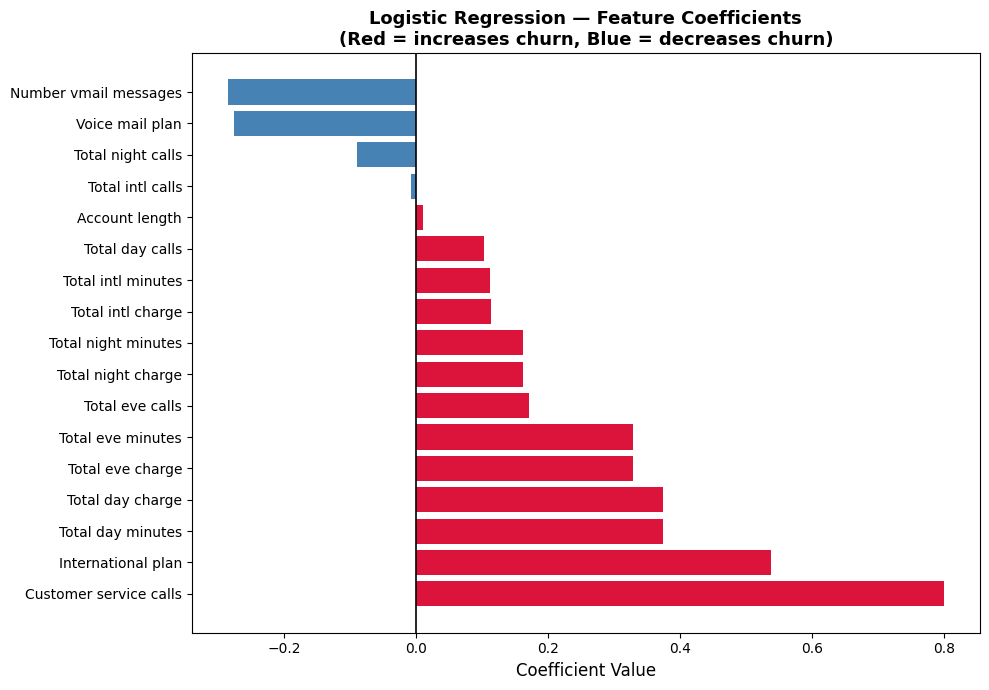

✅ Coefficient plot saved!


In [5]:
# ============================================================
# STEP 5: Interpret Model Coefficients & Odds Ratios
# ============================================================

coeff_df = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : model.coef_[0],
    'Odds Ratio'  : np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False).reset_index(drop=True)

print("=" * 60)
print("     MODEL COEFFICIENTS & ODDS RATIOS")
print("=" * 60)
print(coeff_df.to_string(index=False))
print("=" * 60)

print("""
📌 How to Interpret:
   Coefficient > 0  → Feature INCREASES churn probability
   Coefficient < 0  → Feature DECREASES churn probability
   Odds Ratio > 1   → Higher value = more likely to churn
   Odds Ratio < 1   → Higher value = less likely to churn
""")

# --- Plot: Feature Coefficients ---
import matplotlib.pyplot as plt

colors = ['crimson' if c > 0 else 'steelblue' for c in coeff_df['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=1.2)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases churn, Blue = decreases churn)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150)
plt.show()
print("✅ Coefficient plot saved!")

       MODEL EVALUATION METRICS
  Accuracy  : 85.82%
  Precision : 50.00%
  Recall    : 15.79%
  F1-Score  : 24.00%

=== Full Classification Report ===
              precision    recall  f1-score   support

 Not Churned       0.88      0.97      0.92       115
     Churned       0.50      0.16      0.24        19

    accuracy                           0.86       134
   macro avg       0.69      0.57      0.58       134
weighted avg       0.82      0.86      0.83       134


📌 Metric Interpretation:
   Accuracy  → Overall correct predictions
   Precision → Of predicted churners, how many actually churned?
   Recall    → Of actual churners, how many did we catch?
   F1-Score  → Balance between Precision and Recall
               (important for imbalanced datasets like this one)



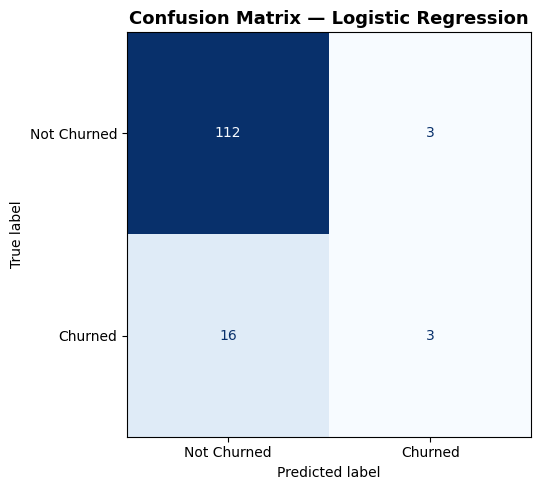

✅ Confusion matrix saved!


In [6]:
# ============================================================
# STEP 6: Evaluate the Model
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# --- Predictions ---
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]   # probability of churn

# --- Core Metrics ---
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("       MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 50)

print("\n=== Full Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

print("""
📌 Metric Interpretation:
   Accuracy  → Overall correct predictions
   Precision → Of predicted churners, how many actually churned?
   Recall    → Of actual churners, how many did we catch?
   F1-Score  → Balance between Precision and Recall
               (important for imbalanced datasets like this one)
""")

# --- Confusion Matrix Plot ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Churned', 'Churned'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

AUC Score : 0.8197

📌 AUC Interpretation:
   AUC = 1.0  → Perfect classifier
   AUC = 0.5  → Random guessing (no skill)
   AUC = 0.8197 → Good discriminating ability



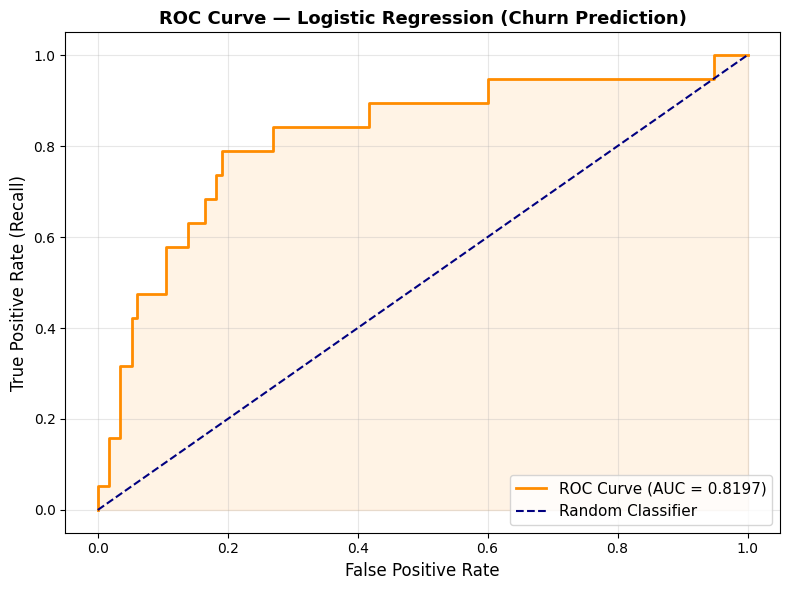

✅ ROC Curve saved!


In [7]:
# ============================================================
# STEP 7: ROC Curve & AUC Score
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"AUC Score : {auc_score:.4f}")
print(f"""
📌 AUC Interpretation:
   AUC = 1.0  → Perfect classifier
   AUC = 0.5  → Random guessing (no skill)
   AUC = {auc_score:.4f} → {'Excellent' if auc_score > 0.9 else 'Good' if auc_score > 0.8 else 'Fair'} discriminating ability
""")

# --- ROC Curve Plot ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Churn Prediction)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")

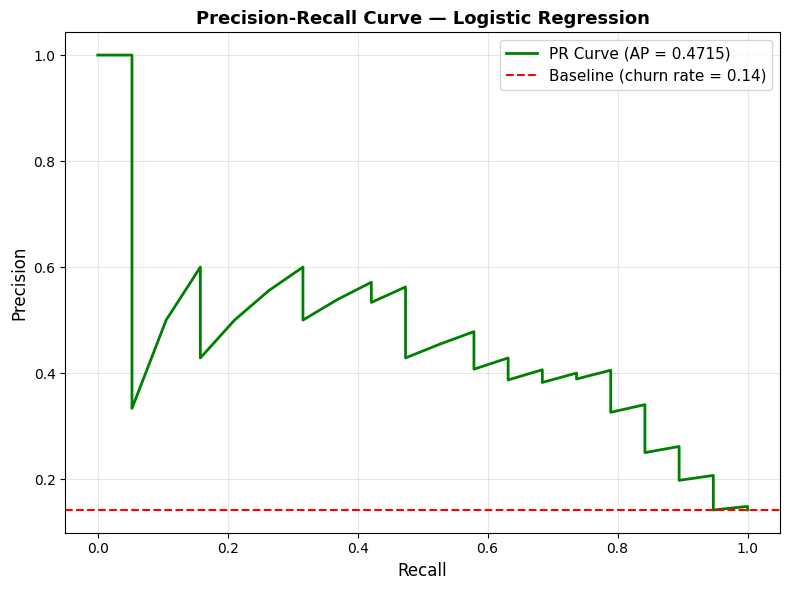

✅ Precision-Recall Curve saved!


In [8]:
# ============================================================
# STEP 8: Precision-Recall Curve (handles class imbalance better)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(rec_curve, prec_curve, color='green', lw=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
plt.axhline(y=y_test.mean(), color='red', linestyle='--',
            label=f'Baseline (churn rate = {y_test.mean():.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Logistic Regression',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()
print("✅ Precision-Recall Curve saved!")

In [9]:
# ============================================================
# STEP 9: Final Summary
# ============================================================

print("=" * 55)
print("     TASK COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset          : Telecom Customer Churn")
print(f"  Total Samples    : {len(df_clean)}")
print(f"  Churn Rate       : {df_clean['Churn'].mean()*100:.1f}% (imbalanced)")
print(f"  Features Used    : {X.shape[1]}")
print(f"  Train / Test     : {len(X_train)} / {len(X_test)}")
print(f"  Model            : Logistic Regression")
print("-" * 55)
print(f"  Accuracy         : {accuracy*100:.2f}%")
print(f"  Precision        : {precision*100:.2f}%")
print(f"  Recall           : {recall*100:.2f}%")
print(f"  F1-Score         : {f1*100:.2f}%")
print(f"  AUC-ROC          : {auc_score:.4f}")
print("-" * 55)

# Top 3 churn drivers
top3 = coeff_df[coeff_df['Coefficient'] > 0].head(3)
print("  Top 3 Churn Drivers:")
for _, row in top3.iterrows():
    print(f"    ▸ {row['Feature']:<30} (OR = {row['Odds Ratio']:.3f})")
print("=" * 55)
print("  ✅ Model Ready for Deployment!")

     TASK COMPLETE — FINAL SUMMARY
  Dataset          : Telecom Customer Churn
  Total Samples    : 667
  Churn Rate       : 14.2% (imbalanced)
  Features Used    : 17
  Train / Test     : 533 / 134
  Model            : Logistic Regression
-------------------------------------------------------
  Accuracy         : 85.82%
  Precision        : 50.00%
  Recall           : 15.79%
  F1-Score         : 24.00%
  AUC-ROC          : 0.8197
-------------------------------------------------------
  Top 3 Churn Drivers:
    ▸ Customer service calls         (OR = 2.224)
    ▸ International plan             (OR = 1.712)
    ▸ Total day minutes              (OR = 1.453)
  ✅ Model Ready for Deployment!
